# 03 Summarizing Data

# Outline of ECE 3

- 01: Welcome to Python
- 02: Computing with Data in Python
- **03: Summarizing Data in Python**
- 04: Predicting from Data with Machine Learning in Python
  - A. Clustering
  - B. Linear regression

<h1>Time for a mid-quarter survey! 🥳 </h1>
<ul>
    <li> Be honest! We want to improve. </li>
</ul>
<div style="display:flex; justify-content:center; margin-top:30px;">
  <img src="figs/03_survey.gif" width="500px" alt="Survey animation">
</div>

# Outline of Unit 03

- **02: Computing with Data in Python**
  - <b>Why do we summarize data?</b>
  - <b>Continous vs. Categorical</b>
      - <b>Summarizing Continous Data</b> 
          - Mean, Median, Mode, Mean Square, Root Mean square, Standard Deviation
      - Summarizing Categorical Data
  - Visualizing Data
      - Histograms, box plots, bar plots, pie charts

<div style="display: flex; gap: 50px;">
  <div style="flex: 1; border: 1px solid #ccc; padding: 10px;">
    <center><img src="figs/03_LouisaCornelis.png" width=500px alt="default"/></center>
  </div>
  <div style="flex: 1; border: 1px solid #ccc; padding: 50px;">
    My name is Louisa Cornelis, I am a 3rd year in Prof. Nina Miolane's lab. 
    I'm a theoretical physicist who is researching how to use neural networks on medical data. 
  </div>
</div>

<div style="display: flex; gap: 40px; align-items: center;">
  <div style="flex: 1; border: 1px solid #ccc; padding: 15px;">
    <h3>A little bit about me:</h3>
    <ul style="margin: 0; padding-left: 20px; line-height: 1.5;">
      <li>I’m from New York City. 🍎</li>
      <li>I studied Physics and Computer Science at Scripps College and Harvey Mudd College.</li>
      <li>I worked in industry at Google and Peloton before starting graduate school.</li>
    </ul>
  </div>

  <div style="flex: 1; border: 1px solid #ccc; padding: 15px; text-align: center;">
    <img src="figs/03_Louisa_angelo.png" width="450px" alt="default" />
  </div>
</div>

<h2>Why do we summarize data?</h2>
<img src="figs/03_sherlock.avif" width="500px">


In [28]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
# Imagine these are individual ride times (in minutes) from a bike-share app
np.random.seed(0)
raw_durations = np.random.randint(1, 120, size=50)
df = pd.DataFrame({"ride_duration_min": raw_durations})

n = 10
# Split into chunks
chunks = [df.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(df), n)]
# Concatenate horizontally
combined = pd.concat(chunks, axis=1)
display(HTML(combined.to_html(index=False)))

ride_duration_min,ride_duration_min,ride_duration_min,ride_duration_min,ride_duration_min
45,115,40,21,89
48,37,88,116,50
118,88,47,81,116
65,71,89,116,30
68,89,82,70,20
68,89,38,80,20
104,13,26,48,15
10,59,78,65,40
84,66,73,83,33
22,103,10,100,66


<ul style="margin: 0; padding-left: 20px; line-height: 1.5;">
      <li>We want to turn <b>raw information</b> into <b>insight</b>. </li>
      <li> Raw data is overwhelming (imagine reading 10,000 customer reviews one by one) </li>
      <li> Summaries help us find patterns, make decisions, and communicate insights </li>
</ul>


Summary statistics:
count     50.000000
mean      63.840000
std       31.799987
min       10.000000
25%       38.500000
50%       67.000000
75%       88.000000
max      118.000000
Name: ride_duration_min, dtype: float64

Mean = 63.8 min, Median = 67.0 min


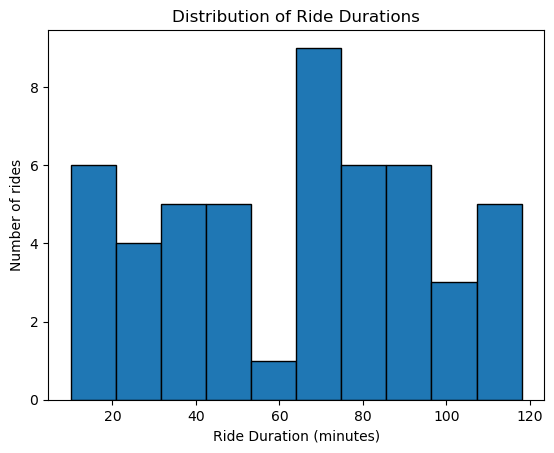

In [29]:
print("\nSummary statistics:")
print(df["ride_duration_min"].describe())

# Compute specific measures
mean_val = df["ride_duration_min"].mean()
median_val = df["ride_duration_min"].median()
print(f"\nMean = {mean_val:.1f} min, Median = {median_val:.1f} min")

# Visualization
plt.hist(df["ride_duration_min"], bins=10, edgecolor="black")
plt.xlabel("Ride Duration (minutes)")
plt.ylabel("Number of rides")
plt.title("Distribution of Ride Durations")
plt.show()

<h1>Real-world example:</h1> On Netflix,  you don't the millions of rating per show or movie, you see an average star rating: "92% match". 

<div style="text-align: center; margin-top: 20px;">
  <img src="figs/03_netflix.webp" alt="Median vs Mean illustration" width="600px">
</div>

<h3> What are other summary stats that you have seen in real life? </h3>

<h1>Real-World Data Examples</h1>

<div style="display:flex; justify-content:center; gap:24px;">

  <!-- each tile is the same size -->
  <div style="width:320px; height:360px; display:flex; align-items:center; justify-content:center; background:#fff; border:1px solid #ddd; overflow:hidden;">
    <img src="figs/03_shohei.webp"
         style="max-width:100%; max-height:100%; object-fit:contain; display:block;">
  </div>

  <div style="width:320px; height:360px; display:flex; align-items:center; justify-content:center; background:#fff; border:1px solid #ddd; overflow:hidden;">
    <img src="figs/03_screentime.jpg"
         style="max-width:100%; max-height:100%; object-fit:contain; display:block;">
  </div>

  <div style="width:320px; height:360px; display:flex; align-items:center; justify-content:center; background:#fff; border:1px solid #ddd; overflow:hidden;">
    <img src="figs/03_waves.png"
         style="max-width:100%; max-height:100%; object-fit:contain; display:block;">
  </div>

</div>

<h1>How we summarize depends on the <i>type</i> of variable </h1>

<h1> Continuous vs. Categorical Variables</h1>

<p><b>Continuous variables</b> represent measurable quantities that can take on any numeric value within a range.</p>
<ul>
  <li>Examples: temperature, age, height, price</li>
</ul>

<p><b>Categorical variables</b> represent groups, labels, or distinct categories rather than numeric values.</p>
<ul>
  <li>Examples: gender, car brand, neighborhood, major</li>
</ul>

<p style="margin-top: 10px;"><i>Think:</i> numbers that can slide on a scale → <b>continuous</b>;  
names that fit into boxes → <b>categorical</b>.</p>


<h1> Which Variables Are Continuous vs. Categorical?</h1>

<p>Look at the variables below — classify each one as <b>Continuous</b> or <b>Categorical</b>.</p>

<table style="width:80%; border-collapse: collapse; font-size: 20px; text-align: left;">
  <thead>
    <tr>
      <th style="border-bottom: 2px solid #ccc; padding: 8px;">Variable</th>
      <th style="border-bottom: 2px solid #ccc; padding: 8px;">Your Answer</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="padding: 8px;">1. Age of a person</td><td style="padding: 8px;">__________</td></tr>
    <tr><td style="padding: 8px;">2. Favorite coffee drink</td><td style="padding: 8px;">__________</td></tr>
    <tr><td style="padding: 8px;">3. Annual income ($)</td><td style="padding: 8px;">__________</td></tr>
    <tr><td style="padding: 8px;">4. City of residence</td><td style="padding: 8px;">__________</td></tr>
    <tr><td style="padding: 8px;">5. Number of siblings</td><td style="padding: 8px;">__________</td></tr>
  </tbody>
</table>


<h1>Answers: Continuous vs. Categorical</h1>

<ul style="font-size: 22px;">
  <li class="fragment">1. <b>Age of a person</b> → Continuous</li>
  <li class="fragment">2. <b>Favorite coffee drink</b> → Categorical</li>
  <li class="fragment">3. <b>Annual income ($)</b> → Continuous</li>
  <li class="fragment">4. <b>City of residence</b> → Categorical</li>
  <li class="fragment">5. <b>Number of siblings</b> → Discrete numeric (can be treated as categorical for plots)</li>
</ul>

<p style="margin-top: 20px; font-size: 18px;">

<h1> How do we summarize Continuous Variables?</h1>
<ul>
  <li>Usually summarized with <b>mean</b>, <b>median</b>, and <b>standard deviation</b></li>
  <li>Visualized with histograms, density plots, or boxplots</li>
</ul>

# Mean

$\color{#EF5645}{\text{Definition}}$: The _mean value_, or _average_ of an $n$-vector $x$ is:
$$\bar{x} = \frac{x_1 + ... + x_n}{n}.$$


$\color{#047C91}{\text{Example}}$: Consider the vector of the blood pressures of a patient recorded every 4 hours during a day $x = (110, 100, 108, 100, 104, 100)$. (in mmHg). Compute the average blood pressure of the patient.

$\color{#003660}{\text{In Python}}$, we use the function `average` or `mean` from `numpy`.

In [ ]:
import numpy as np

x = [110, 100, 108, 100, 104, 100]
np.mean(x), np.average(x)

In [ ]:
np.average(x, weights=[1, 1, 1, 2, 2, 3])
# [110, 100, 108, 100, 100, 104, 104, 100, 100, 100]

In [48]:
x1 = [98, 99, 100, 101, 102]
x2 = [80, 90, 100, 110, 120]
x3 = [60, 70, 80, 90, 100]

# Compute mean vector if stacking into matrix
X = np.array([x1, x2, x3])
mean_vector = np.mean(X, axis=0)
print(np.mean(X,axis=1))
print("\nMean vector (elementwise average across rows):")
print(mean_vector)

[100. 100.  80.]

Mean vector (elementwise average across rows):
[ 79.33333333  86.33333333  93.33333333 100.33333333 107.33333333]


<h2>Should we trust the mean alone?</h2>
<ul style="font-size: 20px; line-height: 1.6; margin-top: 10px;">
  <li>When can the mean be misleading?</li>
  <li>If one number can throw off the mean this much, maybe we need something more robust.</li>
</ul>

In [ ]:
import numpy as np

x = [100, 105, 110, 115, 120]
x_outlier = [100, 105, 110, 115, 200]

print("Mean (normal):", np.mean(x))
print("Mean (with outlier):", np.mean(x_outlier))

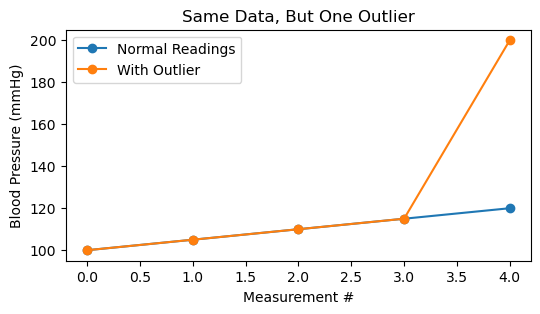

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.plot(x, 'o-', label='Normal Readings')
plt.plot(x_outlier, 'o-', label='With Outlier')
plt.legend()
plt.title("Same Data, But One Outlier")
plt.xlabel("Measurement #")
plt.ylabel("Blood Pressure (mmHg)")
plt.show()

# Median

$\color{#EF5645}{\text{Definition}}$:  
The _median_ of an $n$-vector $x$ is the value that satisfies:
$$P(X \leq \text{median}) = 0.5.$$

$\color{#EF5645}{\text{Remark}}$:  
The median splits the dataset into two equal halves —  
half the observations are less than or equal to it, and half are greater than or equal to it.

$\color{#047C91}{\text{In Practice}}$:  
For a data set $x$ of $n$ elements (sorted from smallest to largest):
$$
\text{If } n \text{ is odd: } \quad \text{median}(x) = x_{(n+1)/2}
$$
$$
\text{If } n \text{ is even: } \quad 
\text{median}(x) = \frac{x_{(n/2)} + x_{(n/2)+1}}{2}
$$

<h2>Real-World Example</h2>

<div style="display: flex; justify-content: center; align-items: center; gap: 40px; margin-top: 20px;">

  <div style="text-align: center;">
    <img src="figs/03_nytimes_title.png" width="500px">
  </div>

  <div style="text-align: center;">
    <img src="figs/03_nytimes_text.png" width="500px">
  </div>

</div>

$\color{#003660}{\text{In Python}}$, we use the function `median` from `numpy`.

In [27]:
import numpy as np

x = [100, 105, 110, 115, 120]
x_outlier = [100, 105, 110, 115, 200]

print("Median (normal):", np.median(x))
print("Median (with outlier):", np.median(x_outlier))

Median (normal): 110.0
Median (with outlier): 110.0


What represents the data best?

# Mode

$\color{#EF5645}{\text{Definition}}$:  
The _mode_ of a dataset is the value that occurs **most frequently**.

$\color{#EF5645}{\text{Remark}}$:  
Unlike the mean or median, the mode can be used for **both categorical and continuous** data.  
There can be one mode (unimodal), multiple modes (bimodal or multimodal),  
or no mode if all values occur equally often.

$\color{#047C91}{\text{In Practice}}$:  
For a dataset $x = (x_1, x_2, ..., x_n)$,  
$$
\text{mode}(x) = \arg\max_{a} \text{count}(x_i = a)
$$

That is, the mode is the value $a$ that appears most frequently in the data.

$\color{#047C91}{\text{Example}}$:  
- Exam scores: $x = (85, 90, 85, 92, 95, 85)$ → $\text{mode}(x) = 85$  
- Favorite drinks: $x = (\text{Latte}, \text{Latte}, \text{Mocha}, \text{Espresso})$ → $\text{mode}(x) = \text{Latte}$

$\color{#003660}{\text{In Python}}$, we use the function `mode` or `multimode` from `numpy`.
Does anyone know the difference?

In [31]:
from statistics import mode, multimode

coffee_orders = ["Latte", "Latte", "Espresso", "Mocha", "Latte", "Espresso"]
scores = [78, 85, 85, 90, 92, 92, 85, 78, 92]

print("Mode (coffee):", mode(coffee_orders))
print("Mode (scores):", mode(scores))
print("All modes (scores):", multimode(scores))

Mode (coffee): Latte
Mode (scores): 85
All modes (scores): [85, 92]


<h2>Mean, Median, and Mode — What Did We Learn?</h2>

<ul>
  <li>The <b>mean</b> is sensitive to extreme values (outliers).</li>
  <li>The <b>median</b> gives a more robust measure of central tendency.</li>
  <li>The <b>mode</b> identifies the <i>most frequent</i> value and works for both categorical and continuous data.</li>
  <li>Together, these describe the <b>center</b> of a dataset — but not its <b>spread</b>.</li>
</ul>

<div style="text-align: center; margin-top: 20px;">
  <img src="figs/03_mean_mod_median.webp" alt="Mean, Median, Mode illustration" width="600px">
</div>

<h3>Next up: How do we measure <i>variability</i>?</h3>

In [39]:
import numpy as np

x1 = [98, 99, 100, 101, 102]    
x2 = [80, 90, 100, 110, 120]

mean1, mean2 = np.mean(x1), np.mean(x2)

print("Mean (x1):", mean1, " Median:", np.median(x1))
print("Mean (x2):", mean2, " Median:", np.median(x2))

Mean (x1): 100.0  Median: 100.0
Mean (x2): 100.0  Median: 100.0


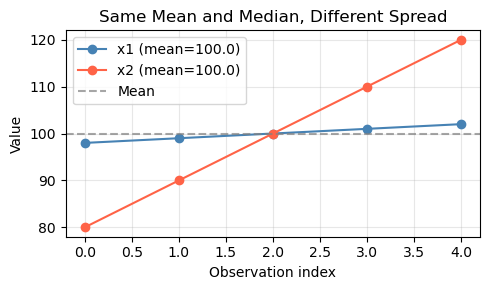

In [45]:
# Compute means for plotting

plt.figure(figsize=(5, 3))

# Plot both datasets
plt.plot(x1, 'o-', label=f'x1 (mean={mean1:.1f})', color='steelblue')
plt.plot(x2, 'o-', label=f'x2 (mean={mean2:.1f})', color='tomato')

plt.axhline(mean1, color='gray', linestyle='--', alpha=0.7, label='Mean')

plt.title("Same Mean and Median, Different Spread")
plt.xlabel("Observation index")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Standard Deviation

$\color{#EF5645}{\text{Definition}}$:  
The _standard deviation_ measures how spread out the data are around the mean.  
It tells us, on average, how far each observation is from the mean.

$$
s = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

$\color{#EF5645}{\text{Remark}}$:  
A small standard deviation means the data are tightly clustered around the mean.  
A large standard deviation means the data are widely spread out.

$\color{#047C91}{\text{In Practice}}$:  
Two datasets can have the same mean and median but very different spreads.  
The standard deviation captures this difference by measuring variability.

$\color{#047C91}{\text{Exercise}}$: Find the standard deviation of x = [2, 4, 4, 4, 5, 5, 7, 9].

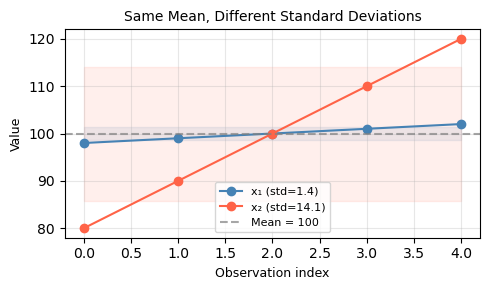

In [50]:
std1, std2 = np.std(x1), np.std(x2)

# Visualization
fig, ax = plt.subplots(figsize=(5,3))

# Plot points
ax.plot(x1, 'o-', color='steelblue', label=f"x₁ (std={std1:.1f})")
ax.plot(x2, 'o-', color='tomato', label=f"x₂ (std={std2:.1f})")

# Add mean lines
ax.axhline(mean1, color='gray', linestyle='--', alpha=0.7, label='Mean = 100')

# Add shaded regions for ±1 standard deviation
ax.fill_between(range(len(x1)),
                mean1 - std1, mean1 + std1,
                color='steelblue', alpha=0.1)
ax.fill_between(range(len(x2)),
                mean2 - std2, mean2 + std2,
                color='tomato', alpha=0.1)

ax.set_title("Same Mean, Different Standard Deviations", fontsize=10)
ax.set_xlabel("Observation index", fontsize=9)
ax.set_ylabel("Value", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h1>Learn Python Pandas, Packages, and Modules</h1>


<b>Web Resources</b>
<br> <a href='https://docs.python.org/3/tutorial/modules.html#packages'>Docs.python.org - Packages</a>


#### <b>What are Python Modules?</b>

Modules are simply python files (.py) which contain python code. This code can define functions, classes, variables etc.


#### <b>Why do we use Modules?</b>

Modules allow us to organize our code by grouping related functionalities, which makes it easier to use and understand. Writing code into smaller, more manageable pieces will help you 1) debug easier, 2) create reusable code and 3) make the code more understandable to the end user.


#### <b>How do we use Modules?</b>

We can use the code in a module by using the <b>import</b> function. For example, let's say we created a .py file called 'Square.py'. Inside this file we defined a function called <b>calculateSquare</b>. 
```python
def calculateSquare(x):
    return x**2
```

We can use the <b>calculateSquare</b> function by using either of the following commands:

```python
import Square 
x = 2
print(Square.calculateSquare(x))

#Output: 4

from Square import calculateSquare
x = 2
print(calculateSquare(x))

#Output: 4

from Square import * #The asterisk imports all functions in the module [not always best practice]
x = 2
print(calculateSquare(x))

#Output: 4
```

#### <b>Where can I find more information on Modules?</b>

[Official python documentation on modules](https://docs.python.org/3.7/tutorial/modules.html)

<h1>Packages</h1>

#### <b>What are Python Packages?</b>

Python packages are an organized collection of related python modules in a single directory. 

#### <b>How do we use Packages?</b>

Packages are used exactly like modules (see the Modules section above).

#### <b>What are some common Packages?</b>

Below are some of the most widely used modules in finance and data science for data analysis:
- Pandas
- Numpy
- Scipy
- Scikit-Learn

Visualizations and dashboard creation:
- Matplotlib
- ipywidgets

In [42]:
###IMPORT PANDAS AND NUMPY PACKAGES###
import numpy as np
import pandas as pd

###CREATING A SERIES###
a = [1,2,3]
b = [1,2,3]
print(a + b)

[1, 2, 3, 1, 2, 3]


In [43]:
###CREATING A TIMESERIES BASED DATAFRAME###
dates = pd.date_range('20130101', periods=6)
df = pd.DataFrame(np.random.randn(6, 3), index=dates, columns=list('ABC'))
df

,A,B,C
2013-01-01,-2.552990,0.653619,0.864436
2013-01-02,-0.742165,2.269755,-1.454366
2013-01-03,0.045759,-0.187184,1.532779
2013-01-04,1.469359,0.154947,0.378163
2013-01-05,-0.887786,-1.980796,-0.347912
2013-01-06,0.156349,1.230291,1.202380


In [44]:
###GET DATA FOR A SINGLE COLUMN###
df['A']

2013-01-01   -2.552990
2013-01-02   -0.742165
2013-01-03    0.045759
2013-01-04    1.469359
2013-01-05   -0.887786
2013-01-06    0.156349
Freq: D, Name: A, dtype: float64

In [ ]:
###CALCULATE SUMMARY STATISTICS###
df.describe()

In [ ]:
###GET THE NUMBER OF ROWS AND COLUMNS###
df.shape

In [ ]:
###GET THE NUMBER OF ROWS ONLY###
len(df)

In [ ]:
###PLOT THE DATAFRAME###
%matplotlib inline
df.plot()

# Outline for Unit 3:

- Who am I
- Now we have real data: reading it form files: Learn Python File i/O
- Summarizing data: continuous versus categorical, histogram (conitnuous): mean, median, standard deviation and barplot (categorical variable)



# Learn Python File I/O


<b>Web Resources</b>
<br> <a href='https://docs.python.org/3/tutorial/inputoutput.html#reading-and-writing-files'>Docs.python.org - Reading and Writing Files</a>


#### <b>What is I/O?</b>

I/O, or input/output, is communication between a computer and the outside world.

Inputs are signals received by the computer. The computer can get inputs from hardware like a keyboard and mouse or from other computers via the internet. Outputs are signals sent by the computer. Your monitor is probably the most obvious output device. An internet modem is an example of a device that both receives inputs (web-pages loading on your browser) and sends outputs (outbound emails).

#### <b>Why do we use I/O?</b>

You can always define data directly in your python code:

```python
example_data = [1, 2, 3, 4, 5]
answer = function(example_data)
```

This is a great way to test functionality but isn't sustainable in the long term. It would be much easier if we could read in data from a file or API as well as write data down to files. This saves us having to manually define data and scales our solutions to handle arbitrary datasets.



## Files

Common file types you likely interact with are CSV and Excel files. The pandas library has a number of convenience functions for reading data from these files and converting them directly into dataframes.

```python
import pandas as pd

csv_dataframe = pd.read_csv('csv_file.csv')
excel_dataframe = pd.read_excel('excel_file.xlsx')
```

Each method accepts the path of the data file as an argument. File paths without a `/` indicate that the data file is in the same directory as the notebook we're writing our code in. If we want to read from a file inside a folder, then we'll need to update the file path, e.g. `folder/csv_file.csv`.

Both methods accept a number of different optional parameters for defining more precisely how you want them to read the data. Visit the [I/O section](https://pandas.pydata.org/docs/reference/io.html) of the online pandas documentation to learn more about these functions.

We can use the `%pwd` [Jupyter magic command](https://ipython.readthedocs.io/en/stable/interactive/magics.html) to find the local directory. Running the following code snippet in a project cell will print the path of your local directory:

```python
x = %pwd
print(x)
```

### Resources
Python has a rich library of packages and functions for dealing with files. [This online tutorial](https://www.programiz.com/python-programming/file-operation) explains in more detail how to use python to deal with File I/O (input and output).

### File IO Examples

1. You're writing some code inside `notebook.ipynb` and want to read the data from `bonds.csv` which is inside the `data` folder (see below). What file path do you need to specify to read the data into a dataframe: `pd.read_csv(...)`?

```
notebook.ipynb
data/
└── bonds.csv
```
`pd.read_csv('data/bonds.csv')`

2. You have a CSV with 3 blank rows at the top of the file. What parameter do you need to pass to the `read_csv` function to ignore these blank rows when reading in the data?

`skiprows=3`

3. A colleague has sent you some tabular data in a [JSON file](https://www.w3schools.com/js/js_json_intro.asp) that you've moved into the same folder as your notebook. You can use pandas to read this data into a dataframe:

`pd.read_json`

In [ ]:
###RENAME COLUMNS###
df = df.rename(columns={"A":"X","B":"Y","C":"Z"})
df

# Outline of Unit 04

- **04: Summarizing Data in Python**
  - Histogram
  - Mean
  - Standard deviation, Variance
  - Covariance, Correlation
  
  Histograms
Mean
Mean Square
Standard deviation


Variance, Standard Deviation, Correlation (David)
Homework: Datacamp: Introduction to Statistics in Python (4h)
Summary Statistics
Random Numbers and Probability
More Distributions and the Central Limit Theorem
Correlation and Experimental Design


For undergrads: aim for 3 min / slide, i.e. 25 slides in 75 min.

In [ ]:
Main packages that we will use: pandas and matplotlib . 

In [ ]:
## Cnotinuous verus categorical

# write definition of continuous and categorical variables

# write examples (question them)

# write in python we can create daatset of continuous or categorical.

# x = ... 


### Histogram

$\color{#EF5645}{\text{Definition}}$: The _histogram_ is ...


$\color{#047C91}{\text{Example}}$: Consider the vector of the blood pressures of a patient recorded every 4 hours during a day $x = (110, 100, 108, 100, 104, 100)$. (in mmHg). Plot the histogram.

$\color{#003660}{\text{In Python}}$, we use the function `hist` from `matplotlib.plt`.

In [ ]:
#

In [ ]:
# Barplot

$\color{#EF5645}{\text{Definition}}$: The _barplot_ is ...


$\color{#047C91}{\text{Example}}$: Consider the vector of the blood pressures of a patient recorded every 4 hours during a day $x = (110, 100, 108, 100, 104, 100)$. (in mmHg). Plot the barplot.


$\color{#003660}{\text{In Python}}$, we use the function

In [ ]:
code here

### Mean Value

$\color{#EF5645}{\text{Definition}}$: The _mean value_, or _average_ of an $n$-vector $x$ is:
$$\bar{x} = \frac{x_1 + ... + x_n}{n}.$$


$\color{#047C91}{\text{Example}}$: Consider the vector of the blood pressures of a patient recorded every 4 hours during a day $x = (110, 100, 108, 100, 104, 100)$. (in mmHg). Compute the average blood pressure of the patient.

In [ ]:
import numpy as np

x = np.array([110, 100, 108, 100, 104, 100])
np.average(x)

In [ ]:
import matplotlib.pyplot as plt


plt.hist(x)
plt.axhline(np.average(x), color='r', linestyle='--', label='Mean')
plt.legend()
plt.show()


##### Outline: 03 Norms and Distances

- Hist
- [Mean](#sec-sd)
- Median
- **[Mean Square, Root Mean Square](#sec-sd)**
- [Standard deviation](#sec-sd)

# Median

$\color{#EF5645}{\text{Definition}}$: The _median_ of an $n$-vector $x$ is the value of $x$ that satisfies:
$$P(x \leq \text{median}) = 0.5.$$

$\color{#EF5645}{\text{Remark}}$: The median is the value of $x$ that splits the vector into two equal halves.



def median(x):
    sorted_x = np.sort(x)
    n = len(sorted_x)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_x[mid - 1] + sorted_x[mid]) / 2.0
    else:
        return sorted_x[mid]



In [ ]:
END OF LEC

### Mean Square and Root Mean Square (RMS) value

$\color{#EF5645}{\text{Definition}}$: The _mean-square value_ of an $n$-vector $x$ is:
$$\frac{x_1^2 + ... + x_n^2}{n} = \frac{||x||^2}{n}.$$

$\color{#EF5645}{\text{Definition}}$: The _root-mean-square (RMS) value_ of an $n$-vector $x$ is:
$$\text{RMS}(x) = \sqrt{\frac{x_1^2 + ... + x_n^2}{n}} = \frac{||x||}{\sqrt{n}}.$$

$\color{#EF5645}{\text{Remark}}$: RMS(x) gives "typical" values of $|x_i|$.

$\color{#047C91}{\text{Exercise}}$: Write a function computing the root-mean-square value in Python.

In [ ]:
def rms(x):
    return np.linalg.norm(x) / np.sqrt(len(x))

# The rms gives typical values:
ones = np.ones(4)
rms(ones)

##### Outline: 03 Norms and Distances


- [Mean Square, Root Mean Square](#sec-sd)
- **[Standard deviation](#sec-sd)**
- Boxplots, quantiles/quartiles
- Exercise on real data

- Scatter plots
- Subplots and many scatterplots
- Covariance
- Correlation between two variables
- Exercise on real data

### Standard Deviation

$\color{#EF5645}{\text{Definition}}$: The _standard deviation_ of the $n$-vector $x$ is:
$$std(x) = rms(x - \bar{x}1) = \frac{||x - \bar{x}.1_n ||}{\sqrt{n}},$$
where $\bar{x}$ is the average of $x$.

$\color{#EF5645}{\text{Remark:}}$ The standard deviation gives the typical amount that $x_i$ varies around $\bar{x}.$

$\color{#6D7D33}{\text{Properties}}$:
1. $std(x) = 0$ if and only if $x = \alpha1$ for some scalar $\alpha$.
2. We have: $rms(x)^2 = \bar{x}^2 + std(x)^2$

### Linear Correlation

$\color{#EF5645}{\text{Definition}}$: The _linear correlation_ of the $n$-vector $x$ and the $n$-vector $y$ is:
$$corr(x, y) = \frac{x - \bar{x}}{||x||}.\frac{y - \bar{y}}{||y||},$$
where $\bar{x}$ is the average of $x$ (same for $y$).

$\color{#EF5645}{\text{Remark:}}$ The correlation gives the typical amount that $y_i$ varies with $x_i$.

### Example: Finance

- $x$: timeseries of returns on an investment (say, in %),
- $\bar{x}$: "mean return" over the time period,
- $std(x)$: how variable is the return = the "risk".

Multiple investments (with different return timeseries $x$) are:
- compared in terms of return and risk.


<center><img src="figs/03_finance.jpg" alt="default" width=900px/></center>

# Poll

https://forms.gle/4pnjXT8d9sYiEaEZA

## Now let's analyse the student poll data!

### But first, let's remember something important about software engineering.

Source: https://imgs.xkcd.com/comics/is_it_worth_the_time.png

In [ ]:
from IPython.display import Image
from IPython.core.display import HTML

img_source = "https://imgs.xkcd.com/comics/is_it_worth_the_time.png"
Image(url=img_source)

# Analysis

TODO: Remove the linear regression from this notebook. Have the notebook /example focus on what has been studied in this unit.

https://colab.research.google.com/drive/1aGwvy7Om26DlzGGVXpXf7uNov3PXImz1?usp=sharing